# 

In [1]:
# Step 1 - Import Required Library -The pandas library is imported(the pd is an alias for pandas - similar to database in sql) - click run

In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
#import numpy as np

In [4]:
# Step 2 - # read_csv File Data to be loaded into pandas Data Frame (similar to tables in sql) - click run

In [5]:
myFlights = pd.read_csv("/anvil/projects/tdm/data/flights/subset/1990.csv") 
myairDF = pd.read_csv("/anvil/projects/tdm/data/flights/subset/airports.csv")

In [6]:
# Step 3 - # Display first 5 rows of data from the election donations data frame(similar to Top 5 in sql) - click run

In [7]:
myFlights.head()

,Year,Month,DayofMonth,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,UniqueCarrier,FlightNum,...,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,1990,1,3,3,1707.0,1630,1755.0,1723,US,29,...,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN
1,1990,1,4,4,1706.0,1630,1807.0,1723,US,29,...,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN
2,1990,1,5,5,1629.0,1630,1715.0,1723,US,29,...,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN
3,1990,1,6,6,1633.0,1630,1718.0,1723,US,29,...,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN
4,1990,1,8,1,1630.0,1630,1726.0,1723,US,29,...,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN


In [8]:
#Create a column named 'Date_of_Delay' by combining Month, DayofMonth, and Year

In [9]:
myFlights['Date_of_Delay'] = myFlights['Month'].astype(str) + '/ ' + myFlights['DayofMonth'].astype(str) + '/ ' + myFlights['Year'].astype(str)

In [10]:
#Group by 'Date_of_Delay' and calculate the average flight delay

In [11]:
myF = myFlights.groupby('Date_of_Delay', dropna=False)['DepDelay'].mean().reset_index(name='Avg_Flight_Delay')

In [12]:
#Sort the results by 'Avg_Flight_Delay' in descending order and display the last 6 rows

In [13]:
myTop_6_Delays=myF.tail(6).sort_values(by='Avg_Flight_Delay',ascending=False)

In [14]:
#Display the final result

In [15]:
print(myTop_6_Delays)

    Date_of_Delay  Avg_Flight_Delay
362    9/ 7/ 1990          7.174473
361    9/ 6/ 1990          5.443598
364    9/ 9/ 1990          4.387991
360    9/ 5/ 1990          3.624815
363    9/ 8/ 1990          3.089669
359    9/ 4/ 1990          2.477655


In [16]:
## .shape = Display how big the data is in the myflights dataframe -  The answer comes as (rows, columns).


In [18]:
myFlights.shape

(5270893, 30)

In [19]:
## .shape = Display how big the data is in the myairDF dataframe -  The answer comes as (rows, columns).


In [20]:
myairDF.shape

(3376, 7)

In [21]:
## This line grabs the column named 'DepDelay' from the myFlights dataset. 'DepDelay' stands for Departure Delay, which shows how many minutes each flight was delayed when leaving the airport.


In [22]:
myFlights['DepDelay']

0          37.0
1          36.0
2          -1.0
3           3.0
4           0.0
           ... 
5270888    22.0
5270889    39.0
5270890    17.0
5270891    11.0
5270892     0.0
Name: DepDelay, Length: 5270893, dtype: float64

In [23]:
# pd.cut() = Categorize into bins the departure delays into hourly intervals (0-60 mins, 60-120 mins, etc.)
# Include special bins for negative values (-float('inf')) and very large delays (float('inf'))
# .value_counts() = Count the frequency of flights in each delay category
# .sort_index() = Sort the results by delay interval
pd.cut(myFlights['DepDelay'], bins=[-float('inf')] + list(range(0,1441,60)) + [float('inf')]).value_counts(dropna = False).sort_index()

DepDelay
(-inf, 0.0]         2966433
(0.0, 60.0]         2111783
(60.0, 120.0]        104240
(120.0, 180.0]        24000
(180.0, 240.0]         7517
(240.0, 300.0]         2630
(300.0, 360.0]         1001
(360.0, 420.0]          366
(420.0, 480.0]          125
(480.0, 540.0]           65
(540.0, 600.0]           35
(600.0, 660.0]           19
(660.0, 720.0]           24
(720.0, 780.0]           20
(780.0, 840.0]           24
(840.0, 900.0]           13
(900.0, 960.0]            8
(960.0, 1020.0]           6
(1020.0, 1080.0]          1
(1080.0, 1140.0]          4
(1140.0, 1200.0]          3
(1200.0, 1260.0]          3
(1260.0, 1320.0]         11
(1320.0, 1380.0]         28
(1380.0, 1440.0]         76
(1440.0, inf]             0
NaN                   52458
Name: count, dtype: int64

In [24]:
## tell pandas to show all columns when displaying data. 
## By default, pandas might hide some columns if there are too many, 
## but this command ensures that every single column will be visible, no matter how many there are.
pd.set_option('display.max_columns',None)
## display the data from the myflights data frame
myFlights

,Year,Month,DayofMonth,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,UniqueCarrier,FlightNum,TailNum,ActualElapsedTime,CRSElapsedTime,AirTime,ArrDelay,DepDelay,Origin,Dest,Distance,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,Date_of_Delay
0,1990,1,3,3,1707.0,1630,1755.0,1723,US,29,NaN,48.0,53,NaN,32.0,37.0,CMH,IND,182.0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,1/ 3/ 1990
1,1990,1,4,4,1706.0,1630,1807.0,1723,US,29,NaN,61.0,53,NaN,44.0,36.0,CMH,IND,182.0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,1/ 4/ 1990
2,1990,1,5,5,1629.0,1630,1715.0,1723,US,29,NaN,46.0,53,NaN,-8.0,-1.0,CMH,IND,182.0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,1/ 5/ 1990
3,1990,1,6,6,1633.0,1630,1718.0,1723,US,29,NaN,45.0,53,NaN,-5.0,3.0,CMH,IND,182.0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,1/ 6/ 1990
4,1990,1,8,1,1630.0,1630,1726.0,1723,US,29,NaN,56.0,53,NaN,3.0,0.0,CMH,IND,182.0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,1/ 8/ 1990
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5270888,1990,12,20,4,2150.0,2128,2233.0,2220,DL,229,NaN,103.0,112,NaN,13.0,22.0,SLC,PDX,630.0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,12/ 20/ 1990
5270889,1990,12,21,5,2207.0,2128,2252.0,2220,DL,229,NaN,105.0,112,NaN,32.0,39.0,SLC,PDX,630.0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,12/ 21/ 1990
5270890,1990,12,22,6,2145.0,2128,2219.0,2220,DL,229,NaN,94.0,112,NaN,-1.0,17.0,SLC,PDX,630.0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,12/ 22/ 1990
5270891,1990,12,23,7,2139.0,2128,2225.0,2220,DL,229,NaN,106.0,112,NaN,5.0,11.0,SLC,PDX,630.0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,12/ 23/ 1990


In [25]:
def myaveragedelay (myDelay: str) -> float:
    """
    The myaveragedelay function calculates the average departure delay (DepDelay) for flights arriving at a specific destination airport.

    Args:
    myDelay (str): A 3-character string representing the destination airport code (e.g., 'IND' for Indianapolis or 'JFK' for John F. Kennedy International Airport).

    Returns:
    avgDelay (float): The computed average departure delay (DepDelay) for flights arriving at the specified destination. The result is returned as a floating-point number.
    
     """
    ##  Load flight data from a CSV file
    myFlights = pd.read_csv("/anvil/projects/tdm/data/flights/subset/1990.csv") 
    ##  # Filter flights by destination and calculate average departure delay
    avgDelay = myFlights[myFlights['Dest'] == myDelay]['DepDelay'].mean()
    ## # Return the calculated average delay
    return avgDelay

In [26]:
## Calculates and returns the average departure delay for flights arriving at Indianapolis airport.

In [27]:
myaveragedelay('IND')

6.341943276578942

In [28]:
## Calculates and returns the average departure delay for flights arriving at JFK airport.

In [29]:
myaveragedelay('JFK')

8.997867848849483

In [30]:
## Combine flight data with airport details using airport codes, like matching friends' screennames to their real names in your contacts.

In [31]:
mergedFlightsDF = myairDF.merge(myFlights, left_on = "iata", right_on = "Origin")

In [32]:
## See how big our data is - like asking 'How many pages is this book?' The answer comes as

In [33]:
mergedFlightsDF.shape

(5270893, 37)

In [34]:
## display the data from the mergedflightsDF data frame

In [35]:
mergedFlightsDF

,iata,airport,city,state,country,lat,long,Year,Month,DayofMonth,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,UniqueCarrier,FlightNum,TailNum,ActualElapsedTime,CRSElapsedTime,AirTime,ArrDelay,DepDelay,Origin,Dest,Distance,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,Date_of_Delay
0,ABE,Lehigh Valley International,Allentown,PA,USA,40.652363,-75.440402,1990,1,4,4,1538.0,1535,1642.0,1635,US,44,NaN,64.0,60,NaN,7.0,3.0,ABE,PIT,253.0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,1/ 4/ 1990
1,ABE,Lehigh Valley International,Allentown,PA,USA,40.652363,-75.440402,1990,1,5,5,1533.0,1535,1626.0,1635,US,44,NaN,53.0,60,NaN,-9.0,-2.0,ABE,PIT,253.0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,1/ 5/ 1990
2,ABE,Lehigh Valley International,Allentown,PA,USA,40.652363,-75.440402,1990,1,6,6,1532.0,1535,1630.0,1635,US,44,NaN,58.0,60,NaN,-5.0,-3.0,ABE,PIT,253.0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,1/ 6/ 1990
3,ABE,Lehigh Valley International,Allentown,PA,USA,40.652363,-75.440402,1990,1,7,7,1537.0,1535,1634.0,1635,US,44,NaN,57.0,60,NaN,-1.0,2.0,ABE,PIT,253.0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,1/ 7/ 1990
4,ABE,Lehigh Valley International,Allentown,PA,USA,40.652363,-75.440402,1990,1,9,2,1540.0,1535,1644.0,1635,US,44,NaN,64.0,60,NaN,9.0,5.0,ABE,PIT,253.0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,1/ 9/ 1990
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5270888,YUM,Yuma MCAS-Yuma International,Yuma,AZ,USA,32.656583,-114.605972,1990,12,26,3,1613.0,1600,1704.0,1652,HP,1145,NaN,51.0,52,NaN,12.0,13.0,YUM,PHX,160.0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,12/ 26/ 1990
5270889,YUM,Yuma MCAS-Yuma International,Yuma,AZ,USA,32.656583,-114.605972,1990,12,28,5,1600.0,1600,1648.0,1652,HP,1145,NaN,48.0,52,NaN,-4.0,0.0,YUM,PHX,160.0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,12/ 28/ 1990
5270890,YUM,Yuma MCAS-Yuma International,Yuma,AZ,USA,32.656583,-114.605972,1990,12,29,6,1614.0,1600,1706.0,1652,HP,1145,NaN,52.0,52,NaN,14.0,14.0,YUM,PHX,160.0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,12/ 29/ 1990
5270891,YUM,Yuma MCAS-Yuma International,Yuma,AZ,USA,32.656583,-114.605972,1990,12,30,7,1600.0,1600,1648.0,1652,HP,1145,NaN,48.0,52,NaN,-4.0,0.0,YUM,PHX,160.0,NaN,NaN,0,NaN,0,NaN,NaN,NaN,NaN,NaN,12/ 30/ 1990


In [36]:
def myaveragedelay (myDelay: str) -> float:
    """
    The myaveragedelay function calculates the average departure delay (DepDelay) for flights leaving at a specific origin airport.

    Args:
    myDelay (str): A 3-character string representing the origin airport code (e.g., 'IND' for Indianapolis).

    Returns:
    avgDelay (float): The computed average departure delay (DepDelay) for flights leaving the specified origin. The result is returned as a floating-point number.
    
     """
    ##  Load flight data from a CSV file
    myFlights = pd.read_csv("/anvil/projects/tdm/data/flights/subset/1990.csv") 
    myairDF = pd.read_csv("/anvil/projects/tdm/data/flights/subset/airports.csv")

    pd.set_option('display.max_columns',None)
    ## mergedFlightsDF = myairDF.merge(myFlights, left_on = "iata", right_on = "Origin")
    
    ##  # Filter flights by origin and calculate average departure delay
    avgDelaybyState = mergedFlightsDF[mergedFlightsDF['Origin'] == myDelay]['DepDelay'].mean()
    ## # Return the calculated average delay
    return avgDelaybyState

In [37]:
## calculate the average wait time where the Origin of the flights is Indianapolis airport

In [38]:
myaveragedelay('IND')

5.9697722567287785

In [39]:
def myaveragedelay (myDelay: str) -> float:
    """
    The myaveragedelay function calculates the average departure delay (DepDelay) for flights leaving at a specific origin airport.

    Args:
    myDelay (str): A 3-character string representing the origin airport code (e.g., 'HOU' for Houston, Tx.

    Returns:
    avgDelay (float): The computed average departure delay (DepDelay) for flights leaving the specified origin. The result is returned as a floating-point number.
    
     """
    ##  Load flight data from a CSV file
    myFlights = pd.read_csv("/anvil/projects/tdm/data/flights/subset/1990.csv") 
    myairDF = pd.read_csv("/anvil/projects/tdm/data/flights/subset/airports.csv")

    pd.set_option('display.max_columns',None)
    ## mergedFlightsDF = myairDF.merge(myFlights, left_on = "iata", right_on = "Origin")
    
    ##  # Filter flights by origin and calculate average departure delay
    avgDelaybyState = mergedFlightsDF[mergedFlightsDF['Origin'] == myDelay]['DepDelay'].mean()
    ## # Return the calculated average delay
    return avgDelaybyState

In [40]:
## calculate the average wait time where the Origin of flights is Houston, TX airport

In [41]:
myaveragedelay('HOU')

8.4465080186239

In [42]:
def myindyflights (myyear: int) -> int:
    """
    The myindyflights function takes a year as the input, and returns the number of flights departing from Indianapolis airport during that year.

    Args:
    myyear (str): This is a year as the input

    Returns:
    myvalue (int): This is the number of flights departing from Indianapolis airport during that year.
    """
    mysubAir = pd.read_csv("/anvil/projects/tdm/data/flights/subset/" + str(myyear) + ".csv", usecols=[16])
    myAirvalue = mysubAir['Origin'].value_counts()["IND"]
    return myAirvalue

In [ ]:
## Counts the number of flights originating from Indianapolis airport (IND) using Pandas' value_counts() method. This provides the total flight frequency for IND

In [43]:
myAirvalue = list(map(myindyflights, range(1987,2009)))
sum(myAirvalue)

796496

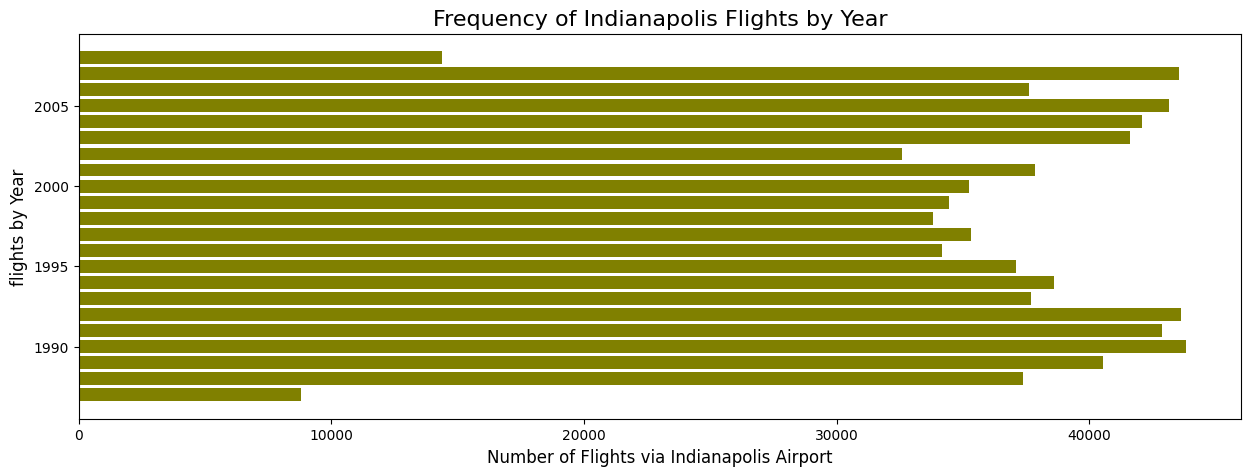

In [53]:
plt.figure(figsize=(15,5)) # <-- figsize=(15,5): Sets the width to 15 inches and height to 5 inches, ensuring a horizontal layout suitable for bar charts with longer labels.
plt.barh(range(1987,2009), myAirvalue, color='olive')
plt.xlabel("Number of Flights via Indianapolis Airport", fontsize=12) #"Number of Flights via Indianapolis Airport": Indicates that each bar corresponds to the Number of Flights via Indianapolis Airport.
plt.ylabel("flights by Year 1987-2008", fontsize=12) #flights by Year: Indicates that the y-axis represents how many times each flight via Indianapolis aiport appears each year in the dataset.
plt.title("Frequency of Indianapolis Flights by Year from 1987-2008", fontsize=16) #Frequency of Indianapolis Flights by Year : Describes what is being visualized (the frequency/nunber of times Inianapolis airport had flights per year in the dataset).
plt.show() #Display Chart - Without this line, no visualization will appear when running scripts in some environments (e.g., Jupyter Notebook or standalone Python scripts).

In [58]:
def myAllflights (myyear: int) -> int:
    """
    The myindyflights function takes a year as the input, and returns the number of flights departing from all airports during that year.

    Args:
    myyear (str): This is a year as the input

    Returns:
    myvalue (int): This is the number of flights departing from All airports during that year.
    """
    mysubAir = pd.read_csv("/anvil/projects/tdm/data/flights/subset/" + str(myyear) + ".csv", usecols=[16])
    myAllvalue = mysubAir['Origin'].value_counts()
    return myAllvalue

In [ ]:
# Calculate Total Flights Across All Airports

In [66]:
myAllvalue = list(map(myAllflights, range(1987,2008)))
sum(myAllvalue)

Origin
ABE    118169.0
ABI         NaN
ABQ    719178.0
ABY         NaN
ACK         NaN
         ...   
XNA         NaN
YAK     14279.0
YAP         NaN
YKM         NaN
YUM         NaN
Name: count, Length: 343, dtype: float64

In [ ]:
# Sums flight totals across all years (sum(axis=1)).

In [67]:
pd.concat(myAllvalue, axis=1).sum(axis=1)

Origin
ORD    6247062.0
ATL    5686440.0
DFW    5429699.0
LAX    3873404.0
DEN    3078462.0
         ...    
INL        218.0
BJI        128.0
MTH        128.0
GLH          2.0
MKC          1.0
Length: 343, dtype: float64

In [ ]:
## Identifies the top 10 airports with the highest cumulative flight frequencies across all years.

In [68]:
myTop_Airports = pd.concat(myAllvalue, axis=1).sum(axis=1).sort_values().tail(10)

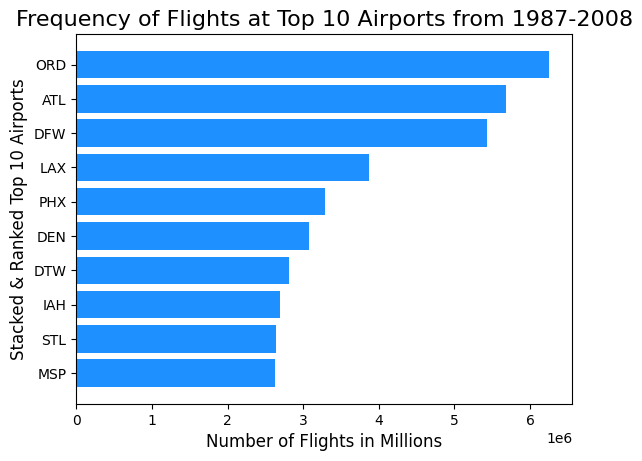

In [71]:
plt.barh(myTop_Airports.index, myTop_Airports, color='dodgerblue')
plt.xlabel("Number of Flights in Millions", fontsize=12) #"Number of Flights via Indianapolis Airport": Indicates that each bar corresponds to the Number of Flights via Indianapolis Airport.
plt.ylabel("Stacked & Ranked Top 10 Airports", fontsize=12) #flights by Year: Indicates that the y-axis represents how many times each flight via Indianapolis aiport appears each year in the dataset.
plt.title("Frequency of Flights at Top 10 Airports from 1987-2008", fontsize=16) #Frequency of Indianapolis Flights by Year : Describes what is being visualized (the frequency/nunber of times Inianapolis airport had flights per year in the dataset).
plt.show() #Display Chart - Without this line, no visualization will appear when running scripts in some environments (e.g., Jupyter Notebook or standalone Python scripts).